## Brain Tumor Detection
### [Exploratory Data Analysis (EDA)]

#### Loading the Dataset from kagglehub

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset",
    output_dir="../data/brain-tumor-mri-dataset",
)

print("Path to dataset files:", path)

/home/galahad/Projects/DATA-SCIENCE/brain-tumor-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: ../data/brain-tumor-mri-dataset


#### Reading the dataset

In [ ]:
import os

train_dir = "../data/brain-tumor-mri-dataset/Training"
test_dir = "../data/brain-tumor-mri-dataset/Testing"

# To load and shuffle the training data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    label_dir = os.path.join(train_dir, label)
    for img_name in os.listdir(label_dir):
        train_paths.append(os.path.join(label_dir, img_name))
        train_labels.append(label)

print(f"Number of training samples: {len(train_paths)}")
print(f"Unique labels: {set(train_labels)}")

Number of training samples: 5600
Unique labels: {'notumor', 'meningioma', 'pituitary', 'glioma'}


#### Shuffling the training data

In [3]:
from sklearn.utils import shuffle

for label in os.listdir(test_dir):
    label_dir = os.path.join(test_dir, label)
    print(f"Total test samples for label '{label}': {len(os.listdir(label_dir))}")
    for img_name in os.listdir(label_dir):
        print(f"Test image: {os.path.join(label_dir, img_name)} with label: {label}")
        train_paths.append(os.path.join(label_dir, img_name))
        train_labels.append(label)


train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

Total test samples for label 'glioma': 400
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_1.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_10.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_100.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_101.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_102.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_103.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_104.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_105.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_106.jpg with label: glioma
Test image: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_107.jpg with label: glioma
Test image: ../data/brain-tumor-mri-data

#### Visualizing the dataset

1. Visualizing the training set

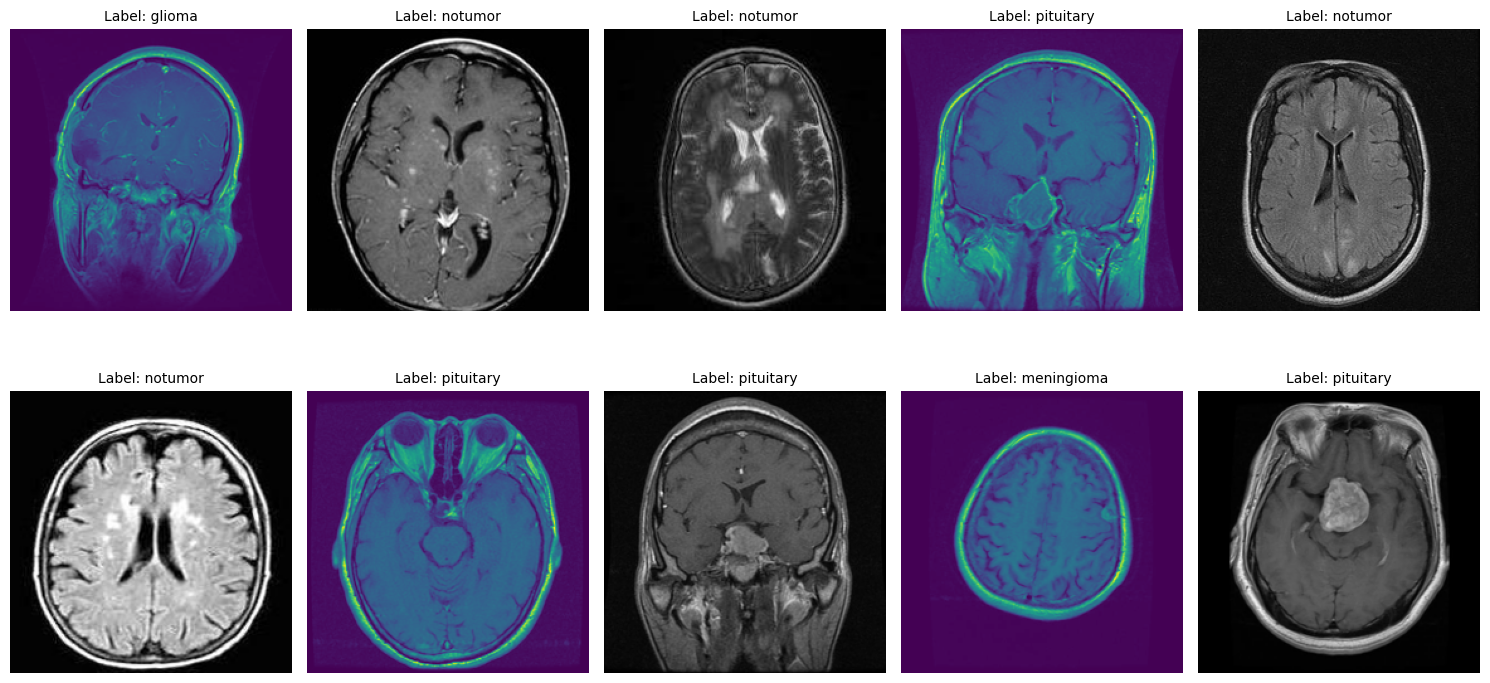

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis("off")  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

2. Visualizing the testing set

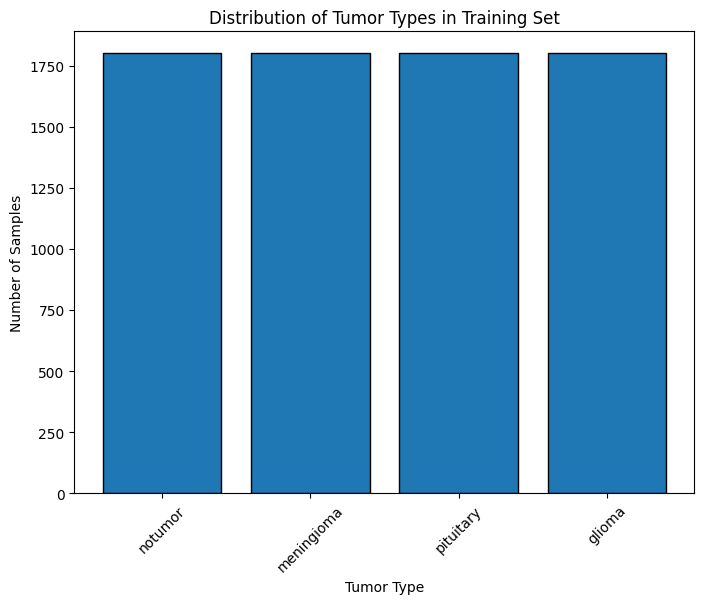

In [5]:
# Plot the distribution of tumor types in the training set
plt.figure(figsize=(8, 6))
plt.bar(
    *zip(*[(label, train_labels.count(label)) for label in set(train_labels)]),
    edgecolor="black",
)
plt.title("Distribution of Tumor Types in Training Set")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()